# Task 2 — Imaging Model (MONAI CNN)
**COMP41840 AI for Health**  
**Owner:** Thomas  
**Goal:** Binary classification — benign vs malignant — from ultrasound images using a MONAI DenseNet121


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import monai
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, ScaleIntensity,
    Resize, RandFlip, RandRotate, ToTensor
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATA_ROOT = Path('../data/raw')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / 'figures').mkdir(exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

_SRC = Path('../src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))
from patient_split import (
    kaggle_multimodal_available,
    build_aligned_manifest,
    assign_split_manifest,
    save_patient_split,
    sort_test_by_patient,
)
USE_ALIGNED = kaggle_multimodal_available(DATA_ROOT)
print('Aligned multi-modal (shared split):', USE_ALIGNED)

Using device: cuda
Aligned multi-modal (shared split): True


## 2.1 — Build Image/Label Lists (benign=0, malignant=1)

In [2]:
# Patient-aligned split (matches Task 3) when Kaggle multi-modal files are present.
test_patient_ids = None
if USE_ALIGNED:
    manifest = build_aligned_manifest(DATA_ROOT)
    manifest = assign_split_manifest(manifest, SEED)
    save_patient_split(manifest, RESULTS_DIR)
    train_df = manifest.loc[manifest['split'] == 'train']
    val_df = manifest.loc[manifest['split'] == 'val']
    test_df = manifest.loc[manifest['split'] == 'test']
    X_train = train_df['image_path'].tolist()
    y_train = train_df['label_enc'].astype(int).tolist()
    X_val = val_df['image_path'].tolist()
    y_val = val_df['label_enc'].astype(int).tolist()
    X_test = test_df['image_path'].tolist()
    y_test = test_df['label_enc'].astype(int).tolist()
    test_patient_ids = test_df['patient_id'].astype(str).tolist()
    labels = manifest['label_enc'].astype(int).tolist()
    print(f'Aligned patients: {len(manifest)} (benign={sum(1 for v in labels if v==0)}, malignant={sum(labels)})')
    print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')
else:
    image_paths, labels = [], []
    MAX_PER_CLASS = 200 if DEVICE.type == 'cpu' else None
    rng = np.random.default_rng(SEED)
    for cls, label in [('benign', 0), ('malignant', 1)]:
        direct_dir = DATA_ROOT / cls / 'images'
        nested_dirs = sorted((DATA_ROOT / 'dataset').glob(f'dataset*/{cls}/images'))
        paths = []
        if direct_dir.exists():
            paths.extend(sorted(direct_dir.glob('*.png')))
        for d in nested_dirs:
            paths.extend(sorted(d.glob('*.png')))
        if MAX_PER_CLASS is not None and len(paths) > MAX_PER_CLASS:
            idx = rng.choice(len(paths), size=MAX_PER_CLASS, replace=False)
            paths = [paths[i] for i in sorted(idx)]
        image_paths.extend(paths)
        labels.extend([label] * len(paths))
    if len(image_paths) == 0:
        raise FileNotFoundError(
            f'No images found under {DATA_ROOT}. Check extraction paths and notebook DATA_ROOT.'
        )
    print(f'Total images: {len(image_paths)}')
    print(f'Benign: {labels.count(0)}  |  Malignant: {labels.count(1)}')
    X_train, X_temp, y_train, y_temp = train_test_split(
        image_paths, labels, test_size=0.3, stratify=labels, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
    )
    test_patient_ids = None
    print(f'Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}')

Aligned patients: 647 (benign=437, malignant=210)
Train: 452  Val: 97  Test: 98


## 2.2 — Dataset & DataLoaders

In [3]:
class BreastUltrasoundDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_ds = BreastUltrasoundDataset(X_train, y_train, train_transform)
val_ds   = BreastUltrasoundDataset(X_val,   y_val,   val_transform)
test_ds  = BreastUltrasoundDataset(X_test,  y_test,  val_transform)

# Use single-process loading for notebook execution on Windows to avoid spawn issues
num_workers = 0
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=num_workers)

## 2.3 — Model: MONAI DenseNet121

In [4]:
model = DenseNet121(
    spatial_dims=2,
    in_channels=3,
    out_channels=2  # benign / malignant
).to(DEVICE)

# Class weights to handle imbalance
n_benign    = labels.count(0)
n_malignant = labels.count(1)
weights = torch.tensor([1.0, n_benign / n_malignant]).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Parameters: 6,955,906


## 2.4 — Training Loop

In [5]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0.0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == lbls).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            total_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == lbls).sum().item()
    return total_loss / len(loader.dataset), correct / len(loader.dataset)


# Keep runtime practical on CPU while allowing longer runs on GPU
EPOCHS = 2 if DEVICE.type == 'cpu' else 20
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc = eval_epoch(model,  val_loader,   criterion, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), RESULTS_DIR / 'best_imaging_model.pt')

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.4f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.4f}')

Epoch 01/20 | Train Loss: 0.6109 Acc: 0.6637 | Val Loss: 1.0069 Acc: 0.3196
Epoch 02/20 | Train Loss: 0.5509 Acc: 0.7301 | Val Loss: 0.6781 Acc: 0.6289
Epoch 03/20 | Train Loss: 0.5005 Acc: 0.7611 | Val Loss: 0.5954 Acc: 0.6907
Epoch 04/20 | Train Loss: 0.4905 Acc: 0.7721 | Val Loss: 0.5439 Acc: 0.7216
Epoch 05/20 | Train Loss: 0.4577 Acc: 0.7920 | Val Loss: 0.5713 Acc: 0.7113
Epoch 06/20 | Train Loss: 0.3878 Acc: 0.8119 | Val Loss: 0.7320 Acc: 0.6392
Epoch 07/20 | Train Loss: 0.3808 Acc: 0.8496 | Val Loss: 0.4857 Acc: 0.8144
Epoch 08/20 | Train Loss: 0.3461 Acc: 0.8540 | Val Loss: 0.4629 Acc: 0.7835
Epoch 09/20 | Train Loss: 0.3323 Acc: 0.8584 | Val Loss: 0.4018 Acc: 0.8660
Epoch 10/20 | Train Loss: 0.3019 Acc: 0.8783 | Val Loss: 0.5176 Acc: 0.7938
Epoch 11/20 | Train Loss: 0.2688 Acc: 0.8850 | Val Loss: 0.4363 Acc: 0.8041
Epoch 12/20 | Train Loss: 0.2149 Acc: 0.9336 | Val Loss: 0.5143 Acc: 0.8351
Epoch 13/20 | Train Loss: 0.1994 Acc: 0.9314 | Val Loss: 0.3994 Acc: 0.8351
Epoch 14/20 

## 2.5 — Training Curves

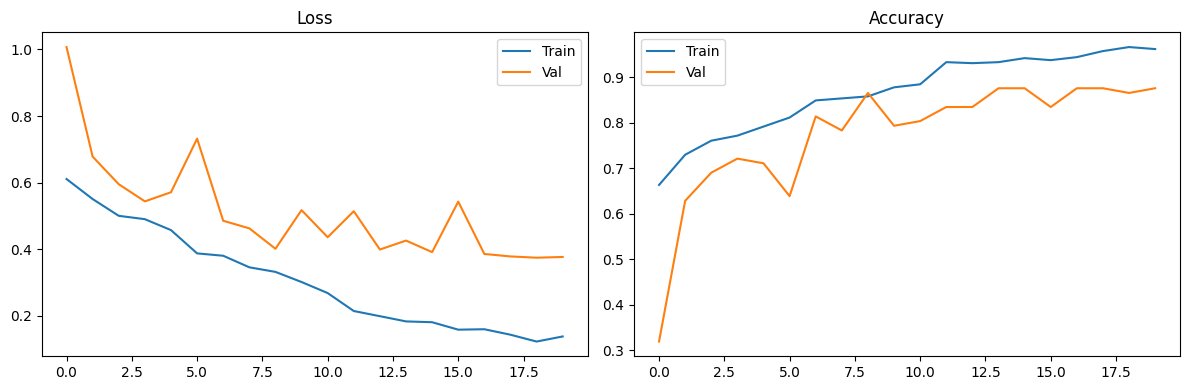

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures/imaging_training_curves.png', dpi=150)
plt.show()

## 2.6 — Test Set Evaluation

              precision    recall  f1-score   support

      benign       0.89      0.83      0.86        66
   malignant       0.69      0.78      0.74        32

    accuracy                           0.82        98
   macro avg       0.79      0.81      0.80        98
weighted avg       0.82      0.82      0.82        98

AUC-ROC: 0.9214


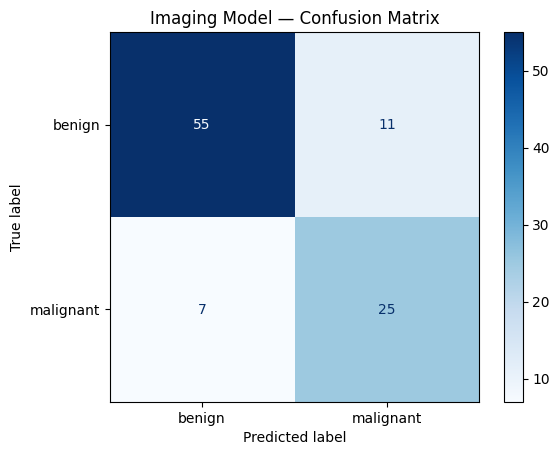

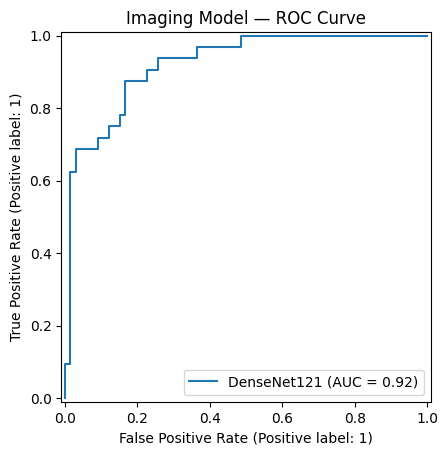

In [7]:
# Load best checkpoint
model.load_state_dict(torch.load(RESULTS_DIR / 'best_imaging_model.pt', map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        out  = model(imgs)
        probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(lbls.numpy())

if test_patient_ids is not None:
    all_probs, all_preds, all_labels, test_patient_ids = sort_test_by_patient(
        test_patient_ids, all_probs, all_preds, all_labels
    )

print(classification_report(all_labels, all_preds, target_names=['benign', 'malignant']))
print(f'AUC-ROC: {roc_auc_score(all_labels, all_probs):.4f}')

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['benign', 'malignant'])
disp.plot(cmap='Blues')
plt.title('Imaging Model — Confusion Matrix')
plt.savefig(RESULTS_DIR / 'figures/imaging_confusion_matrix.png', dpi=150)
plt.show()

# ROC Curve
RocCurveDisplay.from_predictions(all_labels, all_probs, name='DenseNet121')
plt.title('Imaging Model — ROC Curve')
plt.savefig(RESULTS_DIR / 'figures/imaging_roc.png', dpi=150)
plt.show()

In [8]:
# Save metrics for fusion notebook
import json
from sklearn.metrics import precision_score, recall_score, f1_score

imaging_metrics = {
    'auc': round(roc_auc_score(all_labels, all_probs), 4),
    'precision': round(precision_score(all_labels, all_preds), 4),
    'recall': round(recall_score(all_labels, all_preds), 4),
    'f1': round(f1_score(all_labels, all_preds), 4),
    'probs': all_probs,   # needed by fusion notebook
    'preds': all_preds
}

# Save probs/preds for fusion (patient order matches Task 3 when USE_ALIGNED)
np.save(RESULTS_DIR / 'imaging_test_probs.npy', np.array(all_probs))
np.save(RESULTS_DIR / 'imaging_test_labels.npy', np.array(all_labels))
if test_patient_ids is not None:
    np.save(RESULTS_DIR / 'test_patient_ids.npy', np.array(test_patient_ids, dtype=object))

metrics_path = RESULTS_DIR / 'metrics.json'
existing = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}
existing['imaging'] = {k: v for k, v in imaging_metrics.items() if k not in ['probs', 'preds']}
metrics_path.write_text(json.dumps(existing, indent=2))
print('Saved:', imaging_metrics)

Saved: {'auc': 0.9214, 'precision': 0.6944, 'recall': 0.7812, 'f1': 0.7353, 'probs': array([4.16034684e-02, 7.29229348e-03, 4.00330964e-03, 3.83641839e-01,
       7.32871830e-01, 3.49195264e-02, 4.71587991e-03, 2.34633125e-03,
       2.53261905e-02, 8.61454427e-01, 2.56852984e-01, 1.89480752e-01,
       2.39062592e-01, 1.88409343e-01, 1.11354841e-02, 9.27234907e-03,
       2.81847268e-02, 3.00210714e-03, 4.39306460e-02, 6.70115696e-04,
       2.35132724e-02, 8.73583108e-02, 7.54425209e-03, 8.19079399e-01,
       9.49897524e-03, 7.43322633e-03, 2.47957595e-02, 7.55268693e-01,
       4.20824111e-01, 1.21656150e-01, 3.91782932e-02, 4.88470134e-04,
       1.34359404e-01, 8.26638564e-02, 1.21860374e-02, 3.21967937e-02,
       2.79252767e-03, 2.67613918e-01, 3.36084574e-01, 6.69166684e-01,
       3.15834805e-02, 3.56112003e-01, 2.13333522e-03, 9.90592182e-01,
       5.82856178e-01, 5.63497245e-01, 6.37990609e-02, 6.64738834e-01,
       5.02332091e-01, 1.22757265e-02, 6.30540699e-02, 3.208920